In [9]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class QuadState(TypedDict):

    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

In [7]:
def create_equation(state: QuadState):

    equation = f'{state['a']}x^2 + {state['b']}x + {state['c']}'

    return {'equation':equation}


def calculate_discriminant(state: QuadState):

    discriminant = state['b']**2 - (4 * state['a'] * state['c']) 
    return {'discriminant': discriminant}


def real_root(state: QuadState):
    root1 = (-state['b'] + state['discriminant']**0.5) / (2 * state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5) / (2 * state['a'])

    return {'result': f'The roots are {root1} and {root2}'}


def repeated_root(state: QuadState):
    root = (-state['b']  / (2 * state['a']))

    return {'result': f'The repeated root is {root}'}


def no_real_root(state: QuadState):
    
    return {'result': f'No real roots exists'}


def check_condition(state:QuadState) -> Literal["real_root", "repeated_root", "no_real_root"]:

    if(state['discriminant']>0):
        return "real_root"
    elif state['discriminant'] == 0:
        return "repeated_root"
    else:
        return "no_real_root"

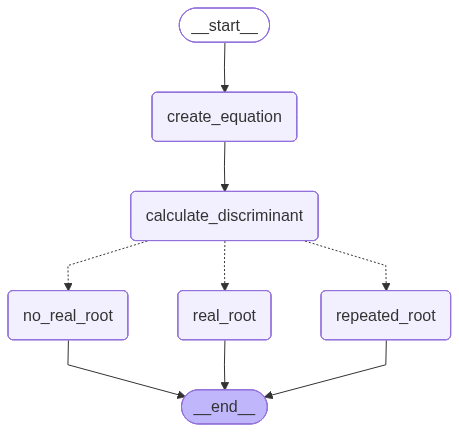

In [10]:
graph = StateGraph(QuadState)

graph.add_node('create_equation',create_equation)

graph.add_node('calculate_discriminant',calculate_discriminant)

graph.add_node('real_root',real_root)
graph.add_node('repeated_root',repeated_root)
graph.add_node('no_real_root',no_real_root)

graph.add_edge(START, 'create_equation')
graph.add_edge('create_equation','calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant', check_condition)

graph.add_edge("real_root", END)
graph.add_edge("repeated_root", END)
graph.add_edge("no_real_root", END)


graph.compile()

In [11]:
workflow = graph.compile()

initial_state = {'a':2, 'b':4, 'c':3}

final_state =  workflow.invoke(initial_state)


print(final_state)

{'a': 2, 'b': 4, 'c': 3, 'equation': '2x^2 + 4x + 3', 'discriminant': -8, 'result': 'No real roots exists'}


In [12]:
workflow = graph.compile()

initial_state = {'a':2, 'b':4, 'c':2}

final_state =  workflow.invoke(initial_state)


print(final_state)

{'a': 2, 'b': 4, 'c': 2, 'equation': '2x^2 + 4x + 2', 'discriminant': 0, 'result': 'The repeated root is -1.0'}


In [13]:
workflow = graph.compile()

initial_state = {'a':1, 'b':4, 'c':2}

final_state =  workflow.invoke(initial_state)


print(final_state)

{'a': 1, 'b': 4, 'c': 2, 'equation': '1x^2 + 4x + 2', 'discriminant': 8, 'result': 'The roots are -0.5857864376269049 and -3.414213562373095'}
